# C0010R05_PARK25_ALLBTMS_1D_CMP_RADAR

本程序比较 **PARK25 空冷优选工况**与**液冷优选工况**，并绘制带浅色底图的论文用综合性能雷达图。

程序仅运行空冷和液冷验证 Notebook，读取两种优选工况的结果，并保存一张 600 dpi PNG 图片；不会读取参数扫描 Excel，也不会生成 Excel、CSV 或 PDF 文件。

雷达图比较五个成本型指标：$T_{\max}$、$\Delta T_{\max}$、$m_{\mathrm{BTMS}}$、$P_{\mathrm{para}}$ 和 $E_{\mathrm{para}}$。每项指标均除以预先定义的设计允许上限，并转换为设计限值利用率：

$$U_i=\frac{x_i}{x_{\mathrm{limit},i}}\times100\%$$

其中，100% 表示达到设计允许上限，数值越小表示该指标越优。默认限值集中设置在第一个代码单元的 `DESIGN_LIMITS` 中，可按最终设计要求直接修改。

绘图时首先在五边形雷达区域铺设浅蓝灰色底色，再叠加网格、空冷曲线和液冷曲线。


In [ ]:
from __future__ import annotations

import os
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager


# -----------------------------------------------------------------------------
# 1. File paths and output names
# -----------------------------------------------------------------------------
WORK_DIR = os.path.abspath("../..")

AIR_NOTEBOOK = WORK_DIR / 'C0008R00_PARK25_AC_1D_VAL.ipynb'
LIQUID_NOTEBOOK = WORK_DIR / 'C0009R00_PARK25_LC_1D_VAL.ipynb'

OUTPUT_DIR = WORK_DIR / 'data_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULT_STEM = 'C0010R02_PARK25_ALLBTMS_1D_RADAR_image'
OUTPUT_PNG = OUTPUT_DIR / f'{RESULT_STEM}.png'


# -----------------------------------------------------------------------------
# 2. Data mode
# -----------------------------------------------------------------------------
# 'run_notebooks': automatically run both validation notebooks and extract data.
# 'manual': use MANUAL_RESULTS below without running the source notebooks.
DATA_MODE = 'run_notebooks'


# -----------------------------------------------------------------------------
# 3. Air-cooling auxiliary-system assumptions
# -----------------------------------------------------------------------------
# The current AC validation notebook contains thermal results only. The following
# values are therefore explicit engineering assumptions for the system-level
# fan-power and mass estimate. Modify them when actual fan/duct data are available.
AC_FAN_EFFICIENCY = 0.35
AC_K_MINOR = 0.0
AC_FAN_MASS_KG = 0.15

# True: use the complete module frontal area to estimate total-system airflow power.
# False: use one representative transverse air domain only.
AC_USE_FULL_MODULE_FLOW_AREA = True


# -----------------------------------------------------------------------------
# 4. Radar normalization based on fixed design limits
# -----------------------------------------------------------------------------
# Each radar value is the percentage of its fixed allowable upper limit:
#
#     utilization = actual value / design limit * 100
#
# All indicators are cost-type indicators, so LOWER utilization is better.
# 100% means the design limit has been reached. Values above the limit are
# clipped at the outer boundary for plotting and reported separately below.
NORMALIZATION_MODE = 'fixed_limit_utilization'

# Fixed design limits used as the common reference for both cooling schemes.
# Tmax = 45 degC is the requested battery-temperature limit. The remaining
# values are initial design-budget settings and should be replaced when the
# final project limits are confirmed.
DESIGN_LIMITS = {
    'Tmax_mission_C': 45.0,        # degC
    'DeltaT_mission_max_C': 5.0,  # degC
    'm_BTMS_kg': 5.0,             # kg
    'P_para_W': 0.5,              # W
    'E_para_J': 500.0,            # J per mission
}

# -----------------------------------------------------------------------------
# 4.1 Radar-chart presentation settings
# -----------------------------------------------------------------------------
# Save a clean radar-only manuscript figure. Raw values and normalized scores
# are displayed in the notebook output but are not written to separate files.
RADAR_LAYOUT = 'radar_only'
SHOW_VERTEX_SCORES = False

# Set to False when the journal caption already explains the figure.
SHOW_FIGURE_TITLE = False

# Radar background. The full 0-100 polygon is filled before gridlines and
# scheme polygons are drawn. Use a very light neutral blue-gray so the base
# remains visible without competing with the data.
RADAR_BACKGROUND_COLOR = '#EEF3F6'
RADAR_BACKGROUND_ALPHA = 1.00
RADAR_GRID_COLOR = '#AEB8C1'
RADAR_BORDER_COLOR = '#59636D'

# Optional alternating score bands. The default is False because one uniform
# background is cleaner for manuscript figures. Set True to display subtle
# 20-point bands beneath the data.
SHOW_BACKGROUND_BANDS = False
RADAR_BAND_COLORS = ['#F7F9FA', '#F1F5F7', '#EBF1F4', '#E5EDF1', '#DFE9EE']

# Muted, print-friendly colors. Line style and marker shape also distinguish the
# two schemes when the figure is printed in grayscale.
SCHEME_STYLE = {
    'Air cooling': {
        'color': '#3F6FA0',
        'linestyle': '-',
        'marker': 'o',
        'markerfacecolor': 'white',
    },
    'Liquid cooling': {
        'color': '#C46A2B',
        'linestyle': '--',
        'marker': 's',
        'markerfacecolor': '#C46A2B',
    },
}

# All five indicators are cost-type indicators: lower values are better.
METRIC_CONFIG = [
    {
        'key': 'Tmax_mission_C',
        'label': r'$T_{\max}$',
        'unit': r'$^{\circ}$C',
        'direction': 'min',
    },
    {
        'key': 'DeltaT_mission_max_C',
        'label': r'$\Delta T_{\max}$',
        'unit': r'$^{\circ}$C',
        'direction': 'min',
    },
    {
        'key': 'm_BTMS_kg',
        'label': r'$m_{\mathrm{BTMS}}$',
        'unit': 'kg',
        'direction': 'min',
    },
    {
        'key': 'P_para_W',
        'label': r'$P_{\mathrm{para}}$',
        'unit': 'W',
        'direction': 'min',
    },
    {
        'key': 'E_para_J',
        'label': r'$E_{\mathrm{para}}$',
        'unit': 'J',
        'direction': 'min',
    },
]


# -----------------------------------------------------------------------------
# 5. Optional manual input
# -----------------------------------------------------------------------------
# Use only when DATA_MODE = 'manual'. Replace every None with the corresponding
# result. The liquid-cooling values below are prefilled from the supplied LC
# validation notebook; AC fields should be filled from the final AC calculation.
MANUAL_RESULTS = {
    'Air cooling': {
        'Tmax_mission_C': 40.763,
        'DeltaT_mission_max_C': None,
        'm_BTMS_kg': AC_FAN_MASS_KG,
        'P_para_W': None,
        'E_para_J': None,
    },
    'Liquid cooling': {
        'Tmax_mission_C': 33.130,
        'DeltaT_mission_max_C': 1.228,
        'm_BTMS_kg': 3.024,
        'P_para_W': 0.0341,
        'E_para_J': 65.44,
    },
}

print(f'Working directory: {WORK_DIR}')
print(f'Data mode: {DATA_MODE}')

Working directory: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS
Data mode: run_notebooks


In [5]:
# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------
def _check_notebook_path(path: Path) -> None:
    if path.is_file():
        return

    visible = '\n'.join(f'  - {p.name}' for p in sorted(WORK_DIR.glob('*.ipynb')))
    if not visible:
        visible = '  - No .ipynb files were found in the current working directory.'

    raise FileNotFoundError(
        f'Notebook not found: {path}\n'
        f'Current working directory: {WORK_DIR}\n'
        'Place the source notebook in this directory or edit its path above.\n'
        f'Visible notebooks:\n{visible}'
    )


def run_notebook_in_current_kernel(path: Path) -> None:
    """Execute a Jupyter notebook through IPython %run in the current kernel."""
    _check_notebook_path(path)

    try:
        ipython = get_ipython()
    except NameError as exc:
        raise RuntimeError(
            'Automatic notebook execution requires a Jupyter/IPython kernel. '
            "Set DATA_MODE = 'manual' when running as a plain Python script."
        ) from exc

    if ipython is None:
        raise RuntimeError(
            'Automatic notebook execution requires a Jupyter/IPython kernel.'
        )

    print(f'\nRunning source notebook: {path.name}')
    ipython.run_line_magic('run', f'"{path}"')


def friction_factor(Re: float) -> float:
    """Darcy friction factor used by the simplified auxiliary-power model."""
    Re = float(Re)
    if Re <= 0.0:
        raise ValueError('Re must be positive.')

    if Re < 2300.0:
        return 64.0 / Re

    if Re >= 4000.0:
        return 0.3164 * Re ** (-0.25)

    f_laminar = 64.0 / 2300.0
    f_turbulent = 0.3164 * 4000.0 ** (-0.25)
    weight = (Re - 2300.0) / (4000.0 - 2300.0)
    return f_laminar + weight * (f_turbulent - f_laminar)


def build_air_summary(namespace: dict) -> dict[str, float]:
    """Extract AC thermal results and calculate total fan power/energy."""
    required_names = [
        'results',
        'D_bat',
        'H_bat',
        'N_r',
        'N_c',
        'V_air',
        's_gap_mm',
        'air_props',
        't_cruise_start',
        't_cruise_end',
    ]
    missing = [name for name in required_names if name not in namespace]
    if missing:
        raise KeyError(
            'The AC validation notebook did not create the required variables: '
            f'{missing}'
        )

    ac_results = namespace['results']
    Tmax = np.asarray(ac_results['Tmax_C'], dtype=float)
    Tmin = np.asarray(ac_results['Tmin_C'], dtype=float)

    if Tmax.shape != Tmin.shape:
        raise ValueError('AC Tmax_C and Tmin_C arrays must have the same shape.')

    D_bat = float(namespace['D_bat'])
    H_bat = float(namespace['H_bat'])
    N_r = int(namespace['N_r'])
    N_c = int(namespace['N_c'])
    V_air = float(namespace['V_air'])
    s_gap = float(namespace['s_gap_mm']) * 1e-3

    rho_air = float(namespace['air_props']['rho_air'])
    mu_air = float(namespace['air_props']['mu_air'])

    # Frontal dimensions and flow length of the complete Park module.
    cell_pitch = D_bat + s_gap
    module_width = D_bat + (N_r - 1) * cell_pitch
    flow_height = H_bat
    full_flow_area = module_width * flow_height
    representative_flow_area = full_flow_area / N_r
    flow_area = (
        full_flow_area
        if AC_USE_FULL_MODULE_FLOW_AREA
        else representative_flow_area
    )

    # Equivalent rectangular-duct hydraulic diameter and streamwise length.
    Dh_air = 2.0 * module_width * flow_height / (module_width + flow_height)
    L_air = D_bat + (N_c - 1) * cell_pitch

    Re_air_power = rho_air * V_air * Dh_air / mu_air
    f_air = friction_factor(Re_air_power)
    dynamic_pressure = 0.5 * rho_air * V_air ** 2
    delta_p = (
        f_air * L_air / Dh_air + AC_K_MINOR
    ) * dynamic_pressure
    volume_flow_rate = V_air * flow_area
    P_fan = delta_p * volume_flow_rate / AC_FAN_EFFICIENCY

    operation_time = float(namespace['t_cruise_end']) - float(
        namespace['t_cruise_start']
    )
    E_fan = P_fan * operation_time

    if AC_USE_FULL_MODULE_FLOW_AREA:
        power_scope = 'complete module frontal area'
    else:
        power_scope = 'one representative air domain'

    print('\nAC auxiliary-power estimate')
    print(f'  Flow-area scope: {power_scope}')
    print(f'  Equivalent hydraulic diameter: {Dh_air * 1e3:.3f} mm')
    print(f'  Estimated pressure drop: {delta_p:.6f} Pa')
    print(f'  Estimated fan power: {P_fan:.6f} W')
    print(f'  Estimated fan energy: {E_fan:.3f} J')
    print(f'  Assumed fan mass: {AC_FAN_MASS_KG:.3f} kg')

    warnings.warn(
        'AC mass currently contains fan mass only; duct/plenum mass is omitted. '
        'Replace AC_FAN_MASS_KG and the pressure-drop assumptions when hardware '
        'data become available.',
        stacklevel=2,
    )

    return {
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(np.max(Tmax - Tmin)),
        'm_BTMS_kg': float(AC_FAN_MASS_KG),
        'P_para_W': float(P_fan),
        'E_para_J': float(E_fan),
    }


def build_liquid_summary(summary: dict | pd.Series) -> dict[str, float]:
    """Map the LC validation summary to the common radar indicators."""
    required = {
        'Tmax_mission_C',
        'DeltaT_mission_max_C',
        'mtotal',
        'P_pump',
        'E_pump_cumulative',
    }
    missing = required.difference(summary.keys())
    if missing:
        raise KeyError(f'LC summary_row is missing columns: {sorted(missing)}')

    return {
        'Tmax_mission_C': float(summary['Tmax_mission_C']),
        'DeltaT_mission_max_C': float(summary['DeltaT_mission_max_C']),
        'm_BTMS_kg': float(summary['mtotal']),
        'P_para_W': float(summary['P_pump']),
        'E_para_J': float(summary['E_pump_cumulative']),
    }


def validate_summary_table(table: pd.DataFrame) -> None:
    required_columns = [item['key'] for item in METRIC_CONFIG]
    missing_columns = set(required_columns).difference(table.columns)
    if missing_columns:
        raise KeyError(f'Missing radar metrics: {sorted(missing_columns)}')

    if table.index.has_duplicates:
        raise ValueError('Scheme names in the result table must be unique.')

    numeric = table[required_columns].apply(pd.to_numeric, errors='coerce')
    if numeric.isna().any().any():
        bad_locations = np.argwhere(numeric.isna().to_numpy())
        details = [
            f'{numeric.index[i]} / {numeric.columns[j]}'
            for i, j in bad_locations
        ]
        raise ValueError(
            'Missing or non-numeric radar values were found at: '
            + ', '.join(details)
        )

    if (numeric < 0.0).any().any():
        raise ValueError('Radar metrics must be non-negative.')


def build_design_limit_table() -> pd.DataFrame:
    """Create and validate the fixed design-limit table."""
    metric_keys = [item['key'] for item in METRIC_CONFIG]
    missing = set(metric_keys).difference(DESIGN_LIMITS)
    extra = set(DESIGN_LIMITS).difference(metric_keys)

    if missing:
        raise KeyError(f'Missing design limits for: {sorted(missing)}')
    if extra:
        raise KeyError(f'Unknown design-limit keys: {sorted(extra)}')

    limits = pd.Series(DESIGN_LIMITS, dtype=float, name='design_limit')
    if not np.isfinite(limits.to_numpy()).all():
        raise ValueError('Every design limit must be finite.')
    if (limits <= 0.0).any():
        bad = limits[limits <= 0.0].index.tolist()
        raise ValueError(f'Design limits must be positive: {bad}')

    return limits.to_frame()


def normalize_metrics(
    raw_table: pd.DataFrame,
    design_limit_table: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return plotted utilization and unclipped utilization percentages."""
    validate_summary_table(raw_table)

    if 'design_limit' not in design_limit_table.columns:
        raise KeyError("The design-limit table needs a 'design_limit' column.")

    utilization = pd.DataFrame(index=raw_table.index)
    plotted = pd.DataFrame(index=raw_table.index)

    for config in METRIC_CONFIG:
        key = config['key']
        if key not in design_limit_table.index:
            raise KeyError(f'Missing design limit for metric: {key}')

        limit = float(design_limit_table.loc[key, 'design_limit'])
        values = raw_table[key].astype(float)
        metric_utilization = 100.0 * values / limit

        utilization[key] = metric_utilization
        plotted[key] = metric_utilization.clip(lower=0.0, upper=100.0)

    return plotted, utilization


def report_limit_exceedances(
    utilization_table: pd.DataFrame,
) -> None:
    """Print any scheme/metric combinations that exceed 100%."""
    exceed_mask = utilization_table > 100.0
    if not exceed_mask.any().any():
        print('\nAll plotted indicators are within the specified design limits.')
        return

    print('\nWarning: the following indicators exceed their design limits:')
    for scheme in utilization_table.index:
        for key in utilization_table.columns:
            value = float(utilization_table.loc[scheme, key])
            if value > 100.0:
                print(f'  {scheme} / {key}: {value:.2f}% of limit')


def configure_plot_style() -> str:
    """Apply a compact SCI-manuscript plotting style."""
    try:
        font_manager.findfont('Times New Roman', fallback_to_default=False)
        font_name = 'Times New Roman'
    except ValueError:
        font_name = 'DejaVu Serif'

    plt.rcParams.update(
        {
            'font.family': font_name,
            'font.size': 9.5,
            'axes.titlesize': 10.5,
            'xtick.labelsize': 9.5,
            'ytick.labelsize': 8.0,
            'legend.fontsize': 9.0,
            'axes.linewidth': 0.85,
            'lines.linewidth': 1.7,
            'lines.markersize': 5.5,
            'mathtext.fontset': 'stix',
            'axes.unicode_minus': False,
            'savefig.dpi': 600,
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
        }
    )
    return font_name


def radar_factory(num_vars: int, frame: str = 'polygon') -> np.ndarray:
    """Create a polygon-frame radar projection with polygon gridlines."""
    from matplotlib.path import Path as MplPath
    from matplotlib.projections import register_projection
    from matplotlib.projections.polar import PolarAxes
    from matplotlib.spines import Spine
    from matplotlib.transforms import Affine2D
    from matplotlib.patches import Circle, RegularPolygon

    theta = np.linspace(0.0, 2.0 * np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return MplPath(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')
            self.set_theta_direction(-1)

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(*args, closed=closed, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                x, y = line.get_data()
                if len(x) > 0 and x[0] != x[-1]:
                    line.set_data(np.append(x, x[0]), np.append(y, y[0]))
            return lines

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            if frame == 'polygon':
                return RegularPolygon(
                    (0.5, 0.5),
                    num_vars,
                    radius=0.5,
                    edgecolor='none',
                )
            raise ValueError(f'Unknown radar frame: {frame}')

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            if frame == 'polygon':
                spine = Spine(
                    axes=self,
                    spine_type='circle',
                    path=MplPath.unit_regular_polygon(num_vars),
                )
                spine.set_transform(
                    Affine2D().scale(0.5).translate(0.5, 0.5)
                    + self.transAxes
                )
                return {'polar': spine}
            raise ValueError(f'Unknown radar frame: {frame}')

    register_projection(RadarAxes)
    return theta


def _metric_axis_labels() -> list[str]:
    """Return short two-line radar-axis labels with units."""
    labels = []
    for item in METRIC_CONFIG:
        labels.append(f"{item['label']}\n({item['unit']})")
    return labels


def _format_raw_value(value: float, key: str) -> str:
    """Format raw values compactly for the comparison table."""
    formats = {
        'Tmax_mission_C': '.2f',
        'DeltaT_mission_max_C': '.2f',
        'm_BTMS_kg': '.3f',
        'P_para_W': '.4f',
        'E_para_J': '.2f',
    }
    return format(float(value), formats.get(key, '.3g'))


def _draw_raw_value_table(axis, raw_table: pd.DataFrame) -> None:
    """Draw a compact raw-value table beside the radar chart."""
    axis.axis('off')
    metric_keys = [item['key'] for item in METRIC_CONFIG]
    metric_names = [item['label'] for item in METRIC_CONFIG]
    plain_units = {
        'Tmax_mission_C': '°C',
        'DeltaT_mission_max_C': '°C',
        'm_BTMS_kg': 'kg',
        'P_para_W': 'W',
        'E_para_J': 'J',
    }
    schemes = list(raw_table.index)
    scheme_headers = [
        name.replace(' cooling', '\ncooling') for name in schemes
    ]

    cell_text = []
    for key in metric_keys:
        row = [_format_raw_value(raw_table.loc[name, key], key) for name in schemes]
        row.append(plain_units[key])
        cell_text.append(row)

    table = axis.table(
        cellText=cell_text,
        rowLabels=metric_names,
        colLabels=scheme_headers + ['Unit'],
        cellLoc='center',
        rowLoc='center',
        loc='center',
        bbox=[0.02, 0.18, 0.96, 0.64],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.55)
        cell.set_edgecolor('#C8C8C8')
        cell.set_facecolor('white')
        if row == 0:
            cell.set_facecolor('#F2F2F2')
            cell.set_text_props(weight='bold')
        if col == -1:
            cell.set_text_props(weight='bold')

    axis.text(
        0.5,
        0.88,
        'Raw indicators',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        transform=axis.transAxes,
    )
    axis.text(
        0.5,
        0.10,
        'Lower raw values indicate better performance.',
        ha='center',
        va='center',
        fontsize=8.2,
        color='#555555',
        transform=axis.transAxes,
    )


def plot_radar(
    plot_table: pd.DataFrame,
    raw_table: pd.DataFrame | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """Draw a compact polygon radar chart for manuscript use."""
    configure_plot_style()

    metric_keys = [item['key'] for item in METRIC_CONFIG]
    metric_labels = _metric_axis_labels()
    n_metrics = len(metric_keys)
    theta = radar_factory(n_metrics, frame='polygon')

    if RADAR_LAYOUT == 'radar_with_table':
        if raw_table is None:
            raise ValueError(
                "raw_table is required when RADAR_LAYOUT = 'radar_with_table'."
            )
        fig = plt.figure(figsize=(8.2, 4.9))
        grid = fig.add_gridspec(
            1,
            2,
            width_ratios=[1.28, 1.0],
            wspace=0.28,
        )
        ax = fig.add_subplot(grid[0, 0], projection='radar')
        table_ax = fig.add_subplot(grid[0, 1])
    elif RADAR_LAYOUT == 'radar_only':
        fig, ax = plt.subplots(
            figsize=(5.6, 5.2),
            subplot_kw={'projection': 'radar'},
        )
        table_ax = None
    else:
        raise ValueError(
            "RADAR_LAYOUT must be 'radar_with_table' or 'radar_only'."
        )

    # ------------------------------------------------------------------
    # Draw the radar background first, beneath gridlines and data polygons.
    # ------------------------------------------------------------------
    full_scale = np.full(n_metrics, 100.0, dtype=float)
    ax.fill(
        theta,
        full_scale,
        facecolor=RADAR_BACKGROUND_COLOR,
        edgecolor='none',
        alpha=RADAR_BACKGROUND_ALPHA,
        zorder=0,
    )

    if SHOW_BACKGROUND_BANDS:
        # Draw from the outside inward so every band remains visible.
        for radius, band_color in zip(
            [100.0, 80.0, 60.0, 40.0, 20.0],
            RADAR_BAND_COLORS,
        ):
            ax.fill(
                theta,
                np.full(n_metrics, radius, dtype=float),
                facecolor=band_color,
                edgecolor='none',
                alpha=1.0,
                zorder=0.2,
            )

    fallback_colors = ['#3F6FA0', '#C46A2B', '#5B8E55', '#7A5A9E']

    for series_index, (scheme_name, row) in enumerate(plot_table.iterrows()):
        values = row[metric_keys].to_numpy(dtype=float)
        style = SCHEME_STYLE.get(
            scheme_name,
            {
                'color': fallback_colors[series_index % len(fallback_colors)],
                'linestyle': '-',
                'marker': 'o',
                'markerfacecolor': 'white',
            },
        )
        color = style['color']

        ax.plot(
            theta,
            values,
            color=color,
            linestyle=style['linestyle'],
            marker=style['marker'],
            markerfacecolor=style['markerfacecolor'],
            markeredgecolor=color,
            markeredgewidth=1.0,
            linewidth=2.0,
            label=scheme_name,
            zorder=4,
        )
        ax.fill(theta, values, color=color, alpha=0.14, zorder=2)

        if SHOW_VERTEX_SCORES:
            for angle, score in zip(theta, values):
                ax.annotate(
                    f'{score:.0f}',
                    xy=(angle, score),
                    xytext=(0, 7),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=7.5,
                    color=color,
                    zorder=6,
                )

    ax.set_varlabels(metric_labels)
    ax.tick_params(axis='x', pad=12)
    ax.set_ylim(0.0, 100.0)
    ax.set_rgrids(
        [20, 40, 60, 80, 100],
        labels=['20', '40', '60', '80', '100'],
        angle=18,
        color='#666666',
        fontsize=7.5,
    )
    ax.yaxis.grid(True, color=RADAR_GRID_COLOR, linewidth=0.70, alpha=0.82)
    ax.xaxis.grid(True, color=RADAR_GRID_COLOR, linewidth=0.70, alpha=0.82)
    ax.spines['polar'].set_color(RADAR_BORDER_COLOR)
    ax.spines['polar'].set_linewidth(1.05)
    ax.set_facecolor('none')

    if SHOW_FIGURE_TITLE:
        ax.set_title(
            'Design-limit utilization of selected BTMS designs',
            pad=25,
            fontweight='bold',
        )

    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=max(1, min(2, len(plot_table))),
        frameon=False,
        handlelength=2.8,
        columnspacing=1.8,
    )

    ax.text(
        0.5,
        -0.22,
        'Design-limit utilization (%): lower is better; 100% = limit',
        ha='center',
        va='center',
        fontsize=8.2,
        color='#555555',
        transform=ax.transAxes,
    )

    if table_ax is not None:
        _draw_raw_value_table(table_ax, raw_table)

    fig.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.98)
    return fig, ax



Running source notebook: C0008R00_PARK25_AC_1D_VAL.ipynb
Result basename: C0008R00_PARK25_AC_1D_VAL
Temperature-curve figure: C0008R00_PARK25_AC_1D_VAL.png
Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920
Fixed validation case:
  case_id = C0008R00
  V_air = 4.000 m/s during cruise
  T_air = 20.000 degC
  s_gap = 3.000 mm
Air properties calculated for the fixed inlet condition.
Running fixed validation case C0008R00: V_air=4.0 m/s, T_air=20.0 degC, s_gap=3.0 mm
Validation case completed.
Maximum mission temperature: 40.763 degC
Time of maximum temperature: 1920.0 s
Minimum-cell temperature at final time: 39.908 degC
Loaded CFD_max: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_val_Liu_20260723\max.out, rows=7681, unit=K -> degC
Loaded CFD_min: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_val_L

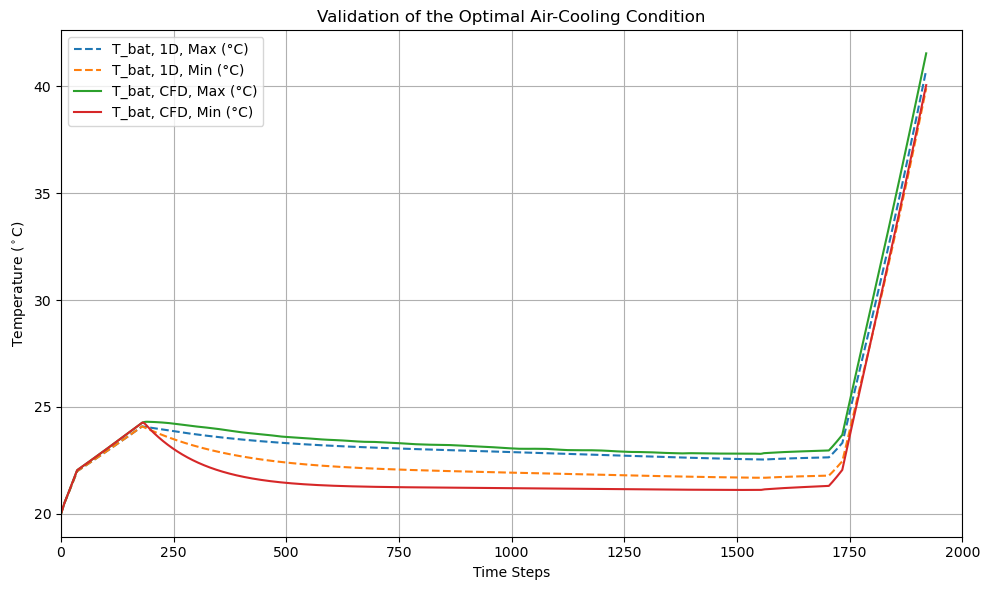

Saved temperature-curve figure: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0008R00_PARK25_AC_1D_VAL.png

AC auxiliary-power estimate
  Flow-area scope: complete module frontal area
  Equivalent hydraulic diameter: 108.769 mm
  Estimated pressure drop: 0.897416 Pa
  Estimated fan power: 0.221995 W
  Estimated fan energy: 306.353 J
  Assumed fan mass: 0.150 kg

Running source notebook: C0009R00_PARK25_LC_1D_VAL.ipynb
Result basename: C0009R00_PARK25_LC_1D_VAL
Notebook file: C0009R00_PARK25_LC_1D_VAL.ipynb
Temperature figure: C0009R00_PARK25_LC_1D_VAL.png
Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920
Selected single condition:
  T_water = 20.0 degC
  m_dot_total = 0.060 kg/s
  Dh = 4.0 mm
  N_ch = 20
  num_cell_seg = 0.800
Water properties calculated at T_water = 20.0 degC.
Running selected single condition...


C:\Users\liu\AppData\Local\Temp\ipykernel_424468\3846857828.py:8: UserWarning: AC mass currently contains fan mass only; duct/plenum mass is omitted. Replace AC_FAN_MASS_KG and the pressure-drop assumptions when hardware data become available.
  air_summary = build_air_summary(globals())


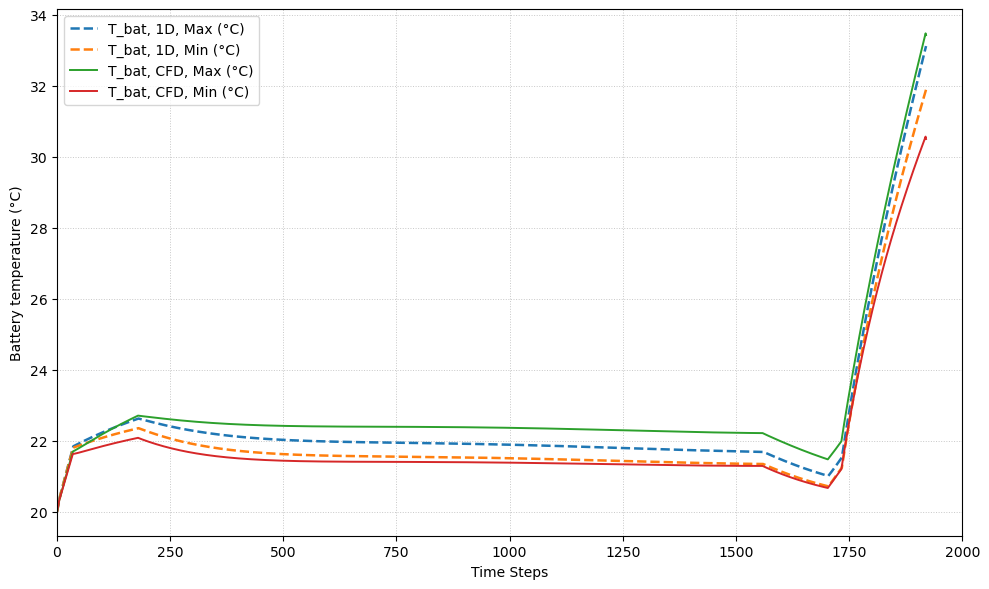


Selected-condition results:
  Tmax = 33.130 °C
  DeltaTmax = 1.228 °C
  P_pump,total = 0.0341 W
  E_pump = 65.44 J
  m_total = 3.024 kg

Saved figure: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0009R00_PARK25_LC_1D_VAL.png

Raw indicators


,Tmax_mission_C,DeltaT_mission_max_C,m_BTMS_kg,P_para_W,E_para_J
Scheme,,,,,
Air cooling,40.762941,0.984673,0.150000,0.221995,306.353348
Liquid cooling,33.130349,1.227544,3.024046,0.034082,65.436726



Fixed design limits


,design_limit
Tmax_mission_C,45.0
DeltaT_mission_max_C,5.0
m_BTMS_kg,5.0
P_para_W,0.5
E_para_J,500.0



Design-limit utilization: fixed_limit_utilization


,Tmax_mission_C,DeltaT_mission_max_C,m_BTMS_kg,P_para_W,E_para_J
Scheme,,,,,
Air cooling,90.58,19.69,3.00,44.40,61.27
Liquid cooling,73.62,24.55,60.48,6.82,13.09



All plotted indicators are within the specified design limits.


In [6]:
# -----------------------------------------------------------------------------
# Run the source notebooks and assemble the in-memory result data
# -----------------------------------------------------------------------------
if DATA_MODE == 'run_notebooks':
    # Run AC first and immediately preserve its results because the LC notebook
    # may reuse some of the same variable names.
    run_notebook_in_current_kernel(AIR_NOTEBOOK)
    air_summary = build_air_summary(globals())

    # Run LC and read the complete-system summary generated by that notebook.
    run_notebook_in_current_kernel(LIQUID_NOTEBOOK)
    if 'summary_row' not in globals():
        raise KeyError(
            "The LC validation notebook did not create 'summary_row'."
        )
    liquid_summary = build_liquid_summary(globals()['summary_row'])

    result_dict = {
        'Air cooling': air_summary,
        'Liquid cooling': liquid_summary,
    }

elif DATA_MODE == 'manual':
    result_dict = MANUAL_RESULTS

else:
    raise ValueError("DATA_MODE must be 'run_notebooks' or 'manual'.")

raw_table = pd.DataFrame.from_dict(result_dict, orient='index')
raw_table.index.name = 'Scheme'

validate_summary_table(raw_table)
design_limit_table = build_design_limit_table()
plot_table, utilization_table = normalize_metrics(
    raw_table,
    design_limit_table,
)
plot_table.index.name = 'Scheme'
utilization_table.index.name = 'Scheme'

print('\nRaw indicators')
display(raw_table.round(6))

print('\nFixed design limits')
display(design_limit_table.round(6))

print(f'\nDesign-limit utilization: {NORMALIZATION_MODE}')
display(utilization_table.round(2))
report_limit_exceedances(utilization_table)


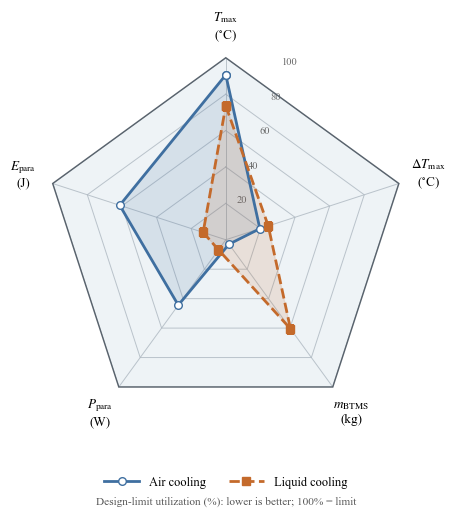


Saved radar-chart image:
  PNG: D:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0010R02_PARK25_ALLBTMS_1D_RADAR_image.png
No Excel, CSV, or PDF files were generated.


In [7]:
# -----------------------------------------------------------------------------
# Draw and save the radar chart
# -----------------------------------------------------------------------------
fig, ax = plot_radar(plot_table, raw_table)

fig.savefig(OUTPUT_PNG, dpi=600, bbox_inches='tight')
plt.show()

print('\nSaved radar-chart image:')
print(f'  PNG: {OUTPUT_PNG.resolve()}')
print('No Excel, CSV, or PDF files were generated.')


## 结果解释注意事项

1. 程序不再读取空冷或液冷参数扫描 Excel，因此不会出现参数扫描文件路径错误。
2. 每个雷达轴表示该方案对固定设计上限的利用率：$U_i=x_i/x_{\mathrm{limit},i}\times100\%$。
3. 100% 表示刚好达到设计允许上限；所有指标均为成本型指标，因此雷达面积越小越好。
4. 超过设计上限的值在图中截断到 100%，但 Notebook 会单独打印超限提示和实际百分比。
5. 默认限值为：$T_{\max}=45\ ^\circ\mathrm{C}$、$\Delta T_{\max}=5\ ^\circ\mathrm{C}$、$m_{\mathrm{BTMS}}=5\ \mathrm{kg}$、$P_{\mathrm{para}}=0.5\ \mathrm{W}$、$E_{\mathrm{para}}=500\ \mathrm{J}$。后三项属于当前比较用设计预算，应按最终系统要求修改。
6. 空冷附加质量目前仍只包含风机质量，未包含风道、集流腔和支撑结构。
